In [1]:
import tomllib
import geopandas as gpd
import pycountry 
import os
import pycountry_convert as pc
import pandas as pd
from openai import OpenAI
import re
import time
import numpy as np
from typing import List, Dict, Tuple, Optional

with open("config.toml", "rb") as f:
    config = tomllib.load(f)

In [2]:
TOKEN = "XXX"

In [3]:
def read_admin(path_admin,adl):
    adms=gpd.read_file(path_admin, layer=f"ADM_{adl}")
    
    adms = adms.rename(columns={'GID_0': 'iso3'})
    iso3_mapping = {'Z01':'IND', 'Z02':'CHN', 'Z03':'CHN', 'Z04':'IND', 'Z05':'IND', 'Z06':'PAK', 'Z07':'IND', 'Z08':'CHN', 'Z09':'IND'}
    adms["iso3"] = adms["iso3"].replace(iso3_mapping)
    adms = adms[~adms["iso3"].isin(["XKO",None])]
    pyi3=[pycountry.countries.get(alpha_3=i3) for i3 in adms.iso3]
    adms=adms[[x is not None for x in pyi3]] # som admin2 will be deleted belonging to ['China', 'India', 'Pakistan', 'Kosovo'] as they are in conflicted areas
    adms["iso2"]=[pycountry.countries.get(alpha_3=i3).alpha_2 for i3 in adms.iso3]

    adms["ADMIN0"]=adms["COUNTRY"]
    if adl ==1:
        adms["ADMIN1"]=adms["NAME_1"]
    elif adl ==2:
        adms["ADMIN1"]=adms["NAME_1"]
        adms["ADMIN2"]=adms["NAME_2"]
    
    
    return adms

In [4]:
gadm2 = read_admin(config["geocoding"]["gadm_path"], 2)


In [5]:
def iso2_to_continent_name(iso2):
    if pd.isna(iso2):
        return None
    try:
        cont_code = pc.country_alpha2_to_continent_code(iso2.upper())
        return pc.convert_continent_code_to_continent_name(cont_code)
    except Exception:
        return None

gadm2["continent"] = gadm2["iso2"].apply(iso2_to_continent_name)

In [6]:
gadm2[["ADMIN0", "ADMIN1", 	"ADMIN2",	"continent"]]

,ADMIN0,ADMIN1,ADMIN2,continent
0,Afghanistan,Badakhshan,Baharak,Asia
1,Afghanistan,Badakhshan,Darwaz,Asia
2,Afghanistan,Badakhshan,Fayzabad,Asia
3,Afghanistan,Badakhshan,Ishkashim,Asia
4,Afghanistan,Badakhshan,Jurm,Asia
...,...,...,...,...
47212,Zimbabwe,Midlands,Redcliff,Africa
47213,Zimbabwe,Midlands,Shurugwi,Africa
47214,Zimbabwe,Midlands,Shurugwi Town,Africa
47215,Zimbabwe,Midlands,Zvishavane,Africa


In [2]:
def apply_spelling_noise(name: str, rng: np.random.Generator) -> str:
    if len(name) < 5:
        return name
    i = rng.integers(1, len(name) - 1)
    return name[:i] + name[i + 1 :]


def feasible_cases(admin1_map: Dict[str, List[str]]) -> List[str]:
    a1s = list(admin1_map)
    n1 = len(a1s)
    n2 = [len(v) for v in admin1_map.values()]

    cases = ["B1", "C2"]  # always possible if ≥1 ADMIN1
    if any(k >= 2 for k in n2):
        cases.append("A1")
    if n1 >= 2:
        cases += ["A2", "B2", "C1", "D1", "D2"]
    return cases


def generate_random_location_sample(
    df: pd.DataFrame,
    n_samples: int = 5_000,
    *,
    max_admin2_per_string: int = 4,
    spelling_noise_prob: float = 0.15,
    random_state: Optional[int] = None,
) -> Tuple[pd.DataFrame, pd.DataFrame]:

    rng = np.random.default_rng(random_state)

    # continent → list of countries
    continent_countries = (
        df.drop_duplicates(["continent", "ADMIN0"])
        .groupby("continent")["ADMIN0"]
        .apply(list)
        .to_dict()
    )

    country_admin1_admin2 = {}
    for country, sub in df.groupby("ADMIN0"):
        country_admin1_admin2[country] = sub.groupby("ADMIN1")["ADMIN2"].apply(list).to_dict()

    continents = list(continent_countries.keys())
    base = n_samples // len(continents)
    remainder = n_samples % len(continents)
    quota = {c: base for c in continents}
    for c in rng.choice(continents, size=remainder, replace=False):
        quota[c] += 1

    country_cases = {
        c: feasible_cases(m)
        for c, m in country_admin1_admin2.items()
        if m
    }

    rows, strings = [], []
    sample_id = 0

    for continent in continents:
        for _ in range(quota[continent]):
            country = rng.choice(continent_countries[continent])
            admin1_map = country_admin1_admin2[country]
            admin1_list = list(admin1_map)

            case = rng.choice(country_cases[country])
            tokens = []
            gold = []

            if case == "A1":
                a1 = rng.choice([k for k, v in admin1_map.items() if len(v) >= 2])
                k = rng.integers(2, min(len(admin1_map[a1]), max_admin2_per_string) + 1)
                chosen = rng.choice(admin1_map[a1], size=k, replace=False)
                for a2 in chosen:
                    tokens.append(a2)
                    gold.append(("ADMIN2", a2, a1))

            elif case == "A2":
                for a1 in rng.choice(admin1_list, 2, replace=False):
                    a2 = rng.choice(admin1_map[a1])
                    tokens.append(a2)
                    gold.append(("ADMIN2", a2, a1))

            elif case == "B1":
                a1 = rng.choice(admin1_list)
                a2 = rng.choice(admin1_map[a1])
                tokens.append(f"{a2} ({a1})")
                gold.append(("ADMIN2", a2, a1))

            elif case == "B2":
                a1a, a1b = rng.choice(admin1_list, 2, replace=False)
                a2a = rng.choice(admin1_map[a1a])
                a2b = rng.choice(admin1_map[a1b])
                tokens += [f"{a2a} ({a1a})", a2b]
                gold += [("ADMIN2", a2a, a1a), ("ADMIN2", a2b, a1b)]

            elif case == "C1":
                for a1 in rng.choice(admin1_list, 2, replace=False):
                    tokens.append(a1)
                    gold.append(("ADMIN1", a1, None))

            elif case == "C2":
                a1 = rng.choice(admin1_list)
                tokens.append(a1)
                gold.append(("ADMIN1", a1, None))

            elif case == "D1":
                a1a, a1b = rng.choice(admin1_list, 2, replace=False)
                a2 = rng.choice(admin1_map[a1a])
                tokens += [a2, a1b]
                gold += [("ADMIN2", a2, a1a), ("ADMIN1", a1b, None)]

            elif case == "D2":
                a1a, a1b = rng.choice(admin1_list, 2, replace=False)
                a2 = rng.choice(admin1_map[a1b])
                tokens += [a1a, a2]
                gold += [("ADMIN1", a1a, None), ("ADMIN2", a2, a1b)]

         
            for i, (lvl, name, _) in enumerate(gold):
                if lvl == "ADMIN2" and rng.random() < spelling_noise_prob:
                    tokens[i] = apply_spelling_noise(tokens[i], rng)

        
            for lvl, name, parent in gold:
                row = {
                    "sample_id": sample_id,
                    "continent": continent,
                    "ADMIN0": country,
                    "case": case,
                    "level": lvl,
                    "ADMIN1": None,
                    "ADMIN2": None,
                    }

                if lvl == "ADMIN1":
                    row["ADMIN1"] = name
                elif lvl == "ADMIN2":
                    row["ADMIN2"] = name
                    row["ADMIN1"] = parent

                rows.append(row)

            strings.append({
                "sample_id": sample_id,
                "continent": continent,
                "ADMIN0": country,
                "case": case,
                "location_string": ", ".join(tokens)
            })

            sample_id += 1

    return pd.DataFrame(rows), pd.DataFrame(strings)



In [7]:
sample_admin2, location_df =generate_random_location_sample(
    gadm2,
    n_samples = 1000,
    max_admin2_per_string = 8,
    spelling_noise_prob = 0.2,
    random_state = 67,
)

In [10]:
sample_admin2

,sample_id,continent,ADMIN0,case,level,ADMIN1,ADMIN2
0,0,Africa,Ethiopia,C1,ADMIN1,Oromia,None
1,0,Africa,Ethiopia,C1,ADMIN1,Gambela Peoples,None
2,1,Africa,Chad,A1,ADMIN2,Chari-Baguirmi,N'Djamena
3,1,Africa,Chad,A1,ADMIN2,Chari-Baguirmi,Baguirmi
4,2,Africa,Sierra Leone,D1,ADMIN2,Southern,Pujehun
...,...,...,...,...,...,...,...
2032,998,South America,Argentina,A1,ADMIN2,San Luis,General Pedernera
2033,998,South America,Argentina,A1,ADMIN2,San Luis,Junín
2034,998,South America,Argentina,A1,ADMIN2,San Luis,La Capital
2035,998,South America,Argentina,A1,ADMIN2,San Luis,Coronel Pringles


In [10]:
sample_admin2.groupby(["sample_id", "ADMIN1"]).size().value_counts()

1    1505
2      28
3      26
4      17
5      15
7      15
6      13
8       9
Name: count, dtype: int64

In [11]:
sample_admin2.continent.value_counts()

continent
North America    365
Asia             344
Africa           342
South America    341
Europe           334
Oceania          311
Name: count, dtype: int64

In [12]:
location_df

,sample_id,continent,ADMIN0,case,location_string
0,0,Africa,Ethiopia,C1,"Oromia, Gambela Peoples"
1,1,Africa,Chad,A1,"N'Djamena, Baguiri"
2,2,Africa,Sierra Leone,D1,"Pujehun, Western"
3,3,Africa,Liberia,A1,"Gbeapo, Webbo"
4,4,Africa,Algeria,C1,"Tamanghasset, Chlef"
...,...,...,...,...,...
995,995,South America,Ecuador,B1,Santa Elea (Santa Elena)
996,996,South America,Bolivia,C2,Potosí
997,997,South America,Bolivia,D1,"Andrés Ibáñez, Oruro"
998,998,South America,Argentina,A1,"Chacabuco, Ayacucho, General Pedernera, Junín,..."


In [13]:
client = OpenAI(
    api_key=TOKEN,
    base_url="https://api-gpt.jrc.ec.europa.eu/v1",
)

def clean_gpt_json(raw_text):
    """
    Extract JSON from GPT response and convert to standard JSON format.
    """
    # Find the first { ... } block
    match = re.search(r"\{.*\}", raw_text, flags=re.DOTALL)
    if not match:
        raise ValueError("No JSON object found in GPT response.")
    
    json_str = match.group(0)

    # Replace smart quotes with normal quotes
    json_str = json_str.replace("“", '"').replace("”", '"').replace("’", "'")

    # Remove trailing commas before } or ]
    json_str = re.sub(r",\s*([\]}])", r"\1", json_str)

    return json.loads(json_str)


def parse_emdat_location(location_string, country):
    """
    Uses GPT to parse an EM-DAT Location string into hierarchical Admin1/Admin2/Admin3 JSON.
    """
    prompt = f"""
You are an expert geographer tasked with parsing disaster location strings into a hierarchical structured format.
Each location can be:
- Admin1: state/province
- Admin2: county/municipality
- Admin3: city/town/village

Rules:
1. Locations may be separated by ';', ',', or 'and'.
2. Text in parentheses indicates the higher-level admin 
   (e.g., "Bamberg (South Carolina)" → Bamberg is Admin2 in South Carolina).
3. Keep the highest-precision locations only:
   - Do not include Admin1 if a more detailed location exists inside it.
   - Do not include Admin2 if an Admin3 exists inside it.
4. Correct minor typos, missing accents, or formatting errors. Always refer to the provided country to disambiguate. Prefer common forms from Google Maps, GADM, or OSM **only if clearly recognizable within that country**. Remove generic descriptors like "area", "village", "region", or "district" **only when not part of the official name**. If unsure, keep the original name. Do not invent, remove, or add any location not in the input string. Return **only JSON** with keys "Admin1", "Admin2", "Admin3", and include Admin1 for each Admin2/Admin3.

Example:
Input: "Belford Roxo Area, Duque de Caxias, Northern Nova Iguaçu, Japeri Village, São João de Meriti, São Gonçalo Region, Mesquita, Nilópolis, Nova Iguaçu, and Queimados Municipalities (Rio de Janeiro); São Paulo, Santa Catarina, Paraná and Rio Grande do Sul"
Country: "Brazil"

Output:
{{
  "Admin1": ["São Paulo", "Santa Catarina", "Paraná", "Rio Grande do Sul"],
  "Admin2": [
    {{"name": "Belford Roxo", "Admin1": "Rio de Janeiro"}},
    {{"name": "Duque de Caxias", "Admin1": "Rio de Janeiro"}},
    {{"name": "Nova Iguaçu", "Admin1": "Rio de Janeiro"}},
    {{"name": "Japeri", "Admin1": "Rio de Janeiro"}},
    {{"name": "São João de Meriti", "Admin1": "Rio de Janeiro"}},
    {{"name": "São Gonçalo", "Admin1": "Rio de Janeiro"}},
    {{"name": "Mesquita", "Admin1": "Rio de Janeiro"}},
    {{"name": "Nilópolis", "Admin1": "Rio de Janeiro"}},
    {{"name": "Queimados", "Admin1": "Rio de Janeiro"}}
  ],
  "Admin3": []
}}

Now parse this location string: "{location_string}"
Country: "{country}"
"""


    try:
        response = client.chat.completions.create(
            model="gpt-4o",
            stream=False,
            messages=[{"role": "user", "content": prompt}]
        )
        # GPT returns text, parse as JSON
        gpt_output = clean_gpt_json(response.choices[0].message.content.strip())
        #print(gpt_output)
        #parsed_json = json.loads(gpt_output)
        return gpt_output
    except Exception as e:
        print(f"Error parsing location with GPT: {e}")
        return None
    
def retry_parse_emdat_location(location_string, country, retries=5, base_wait=1, max_wait=30):
    """
    Retry wrapper that treats a None response as failure and retries with exponential backoff.
    Returns parsed JSON or None after exhausted retries.
    """
    for attempt in range(retries):
        try:
            resp = parse_emdat_location(location_string, country)
            if resp:
                return resp
            else:
                wait_time = min(base_wait * (2 ** attempt), max_wait)
                print(f"[parse] empty/None response for '{location_string[:60]}...' attempt {attempt+1}/{retries}, retrying in {wait_time:.1f}s")
                time.sleep(wait_time)
        except Exception as e:
            errstr = str(e)
            if "429" in errstr or "Too Many Requests" in errstr:
                wait_time = min(base_wait * (2 ** attempt) + random.uniform(0, 2), max_wait)
                print(f"[parse] rate limited on attempt {attempt+1}/{retries} — waiting {wait_time:.1f}s")
                time.sleep(wait_time)
                continue
            else:
                print(f"[parse] error parsing location: {e}")
                return None
    print(f"[parse] giving up after {retries} retries for: {location_string[:80]}")
    return None


In [14]:
parsed_results = []
skipped_samples = []

for idx, row in location_df.iterrows():
    try:
        location_str = row["location_string"]
        country = row["ADMIN0"]
        sample_id = row["sample_id"]
        continent = row["continent"]

        parsed_json = retry_parse_emdat_location(location_str, country, base_wait=4)

        if parsed_json is None:
            print(f"[WARN] Could not parse location for sample_id {sample_id}. Skipping.")
            skipped_samples.append(sample_id)
            continue

        parsed_results.append({
            "sample_id": sample_id,
            "continent": continent,
            "country": country,
            "location_string": location_str,
            "parsed_json": parsed_json
        })

    except Exception as e:
        print(f"[ERROR] Failed processing sample_id {row.get('sample_id', 'NA')}: {e}")
        skipped_samples.append(row.get("sample_id", None))


Error parsing location with GPT: Error code: 429 - {'detail': "{'code': 'RateLimitReached', 'message': 'Requests have exceeded the throughput limit on your Provisioned-Managed deployment. Please retry after 5814 milliseconds. If you continue to exceed your limit, consider increasing the number of provisioned throughput units deployed.'}}"}
[parse] empty/None response for 'Ascension, Jamestown...' attempt 1/5, retrying in 4.0s
Error parsing location with GPT: Error code: 429 - {'detail': "{'code': 'RateLimitReached', 'message': 'Requests have exceeded the throughput limit on your Provisioned-Managed deployment. Please retry after 3716 milliseconds. If you continue to exceed your limit, consider increasing the number of provisioned throughput units deployed.'}}"}
[parse] empty/None response for 'Ogooué-Ivindo, Ngounié...' attempt 1/5, retrying in 4.0s
Error parsing location with GPT: Error code: 429 - {'detail': "{'code': 'RateLimitReached', 'message': 'Requests have exceeded the through

In [15]:
rows = []

for rec in parsed_results:
    sample_id = rec["sample_id"]
    continent = rec["continent"]
    country = rec["country"]
    parsed = rec["parsed_json"]

    for a1 in parsed.get("Admin1", []):
        rows.append({
            "sample_id": sample_id,
            "continent": continent,
            "country": country,
            "level": "Admin1",
            "name": a1,
            "pred_ADMIN1": a1
        })

    for a2 in parsed.get("Admin2", []):
        try:
            rows.append({
                "sample_id": sample_id,
                "continent": continent,
                "country": country,
                "level": "Admin2",
                "name": a2.get("name"),
                "pred_ADMIN1": a2.get("Admin1")
            })
        except Exception as e:
            print(a2)
        
    for a3 in parsed.get("Admin3", []):
        rows.append({
            "sample_id": sample_id,
            "continent": continent,
            "country": country,
            "level": "Admin3",
            "name": a3.get("name"),
            "pred_ADMIN1": a3.get("Admin1")  
        })

parsed_long_df = pd.DataFrame(rows)



In [19]:
len(sample_admin2)

2037

In [20]:
parsed_long_df

,sample_id,continent,country,level,name,pred_ADMIN1
0,0,Africa,Ethiopia,Admin1,Oromia,Oromia
1,0,Africa,Ethiopia,Admin1,Gambela Peoples,Gambela Peoples
2,1,Africa,Chad,Admin3,N'Djamena,N'Djamena
3,1,Africa,Chad,Admin3,Baguirmi,Chari-Baguirmi
4,2,Africa,Sierra Leone,Admin1,Western,Western
...,...,...,...,...,...,...
1984,998,South America,Argentina,Admin2,General Pedernera,San Luis
1985,998,South America,Argentina,Admin2,Junín,Buenos Aires
1986,998,South America,Argentina,Admin2,La Capital,Santa Fe
1987,998,South America,Argentina,Admin2,Coronel Pringles,Buenos Aires


In [21]:
parsed_long_df.level.value_counts()

level
Admin2    998
Admin1    513
Admin3    478
Name: count, dtype: int64

In [22]:
gt_df = sample_admin2.rename(columns={
    "ADMIN2": "name",
    "ADMIN1": "true_ADMIN1"
})[["sample_id", "name", "true_ADMIN1", "continent", "ADMIN0"]]


In [23]:
import unicodedata
import re

def normalize_name(s):
    if not isinstance(s, str):
        return None

    s = unicodedata.normalize("NFKD", s)
    s = "".join(c for c in s if not unicodedata.combining(c))
    s = s.lower()
    s = re.sub(r"[-_]", " ", s)
    s = re.sub(r"[^a-z0-9\s]", "", s)
    s = re.sub(r"\s+", " ", s).strip()

    return s


In [24]:
gold = sample_admin2.copy()

gold = gold.rename(columns={
    "ADMIN0": "country",
    "level": "level_gold"
})

gold["name"] = np.where(
    gold["level_gold"] == "ADMIN2",
    gold["ADMIN2"],
    gold["ADMIN1"]
)

gold["true_ADMIN1"] = np.where(
    gold["level_gold"] == "ADMIN2",
    gold["ADMIN1"],
    None
)

gold["name_norm"] = gold["name"].apply(normalize_name)
gold["true_ADMIN1_norm"] = gold["true_ADMIN1"].apply(normalize_name)

gold = gold[[
    "sample_id", "continent", "country", "case",
    "level_gold", "name", "name_norm",
    "true_ADMIN1", "true_ADMIN1_norm"
]]


In [25]:
pred = parsed_long_df.copy()

pred["level_pred"] = pred["level"].str.replace("Admin", "ADMIN")

pred["name_norm"] = pred["name"].apply(normalize_name)
pred["pred_ADMIN1_norm"] = pred["pred_ADMIN1"].apply(normalize_name)

pred = pred[[
    "sample_id", "continent", "country",
    "level_pred", "name", "name_norm",
    "pred_ADMIN1", "pred_ADMIN1_norm"
]]


In [28]:
gold

,sample_id,continent,country,case,level_gold,name,name_norm,true_ADMIN1,true_ADMIN1_norm
0,0,Africa,Ethiopia,C1,ADMIN1,Oromia,oromia,None,None
1,0,Africa,Ethiopia,C1,ADMIN1,Gambela Peoples,gambela peoples,None,None
2,1,Africa,Chad,A1,ADMIN2,N'Djamena,ndjamena,Chari-Baguirmi,chari baguirmi
3,1,Africa,Chad,A1,ADMIN2,Baguirmi,baguirmi,Chari-Baguirmi,chari baguirmi
4,2,Africa,Sierra Leone,D1,ADMIN2,Pujehun,pujehun,Southern,southern
...,...,...,...,...,...,...,...,...,...
2032,998,South America,Argentina,A1,ADMIN2,General Pedernera,general pedernera,San Luis,san luis
2033,998,South America,Argentina,A1,ADMIN2,Junín,junin,San Luis,san luis
2034,998,South America,Argentina,A1,ADMIN2,La Capital,la capital,San Luis,san luis
2035,998,South America,Argentina,A1,ADMIN2,Coronel Pringles,coronel pringles,San Luis,san luis


In [26]:
pred

,sample_id,continent,country,level_pred,name,name_norm,pred_ADMIN1,pred_ADMIN1_norm
0,0,Africa,Ethiopia,ADMIN1,Oromia,oromia,Oromia,oromia
1,0,Africa,Ethiopia,ADMIN1,Gambela Peoples,gambela peoples,Gambela Peoples,gambela peoples
2,1,Africa,Chad,ADMIN3,N'Djamena,ndjamena,N'Djamena,ndjamena
3,1,Africa,Chad,ADMIN3,Baguirmi,baguirmi,Chari-Baguirmi,chari baguirmi
4,2,Africa,Sierra Leone,ADMIN1,Western,western,Western,western
...,...,...,...,...,...,...,...,...
1984,998,South America,Argentina,ADMIN2,General Pedernera,general pedernera,San Luis,san luis
1985,998,South America,Argentina,ADMIN2,Junín,junin,Buenos Aires,buenos aires
1986,998,South America,Argentina,ADMIN2,La Capital,la capital,Santa Fe,santa fe
1987,998,South America,Argentina,ADMIN2,Coronel Pringles,coronel pringles,Buenos Aires,buenos aires


In [72]:
merged = gold.merge(
    pred,
    on=["sample_id", "country", "name_norm"],
    how="outer",
    suffixes=("_gold", "_pred"),
    indicator=True
)


In [73]:
tp = (merged["_merge"] == "both").sum()
fp = (merged["_merge"] == "right_only").sum()
fn = (merged["_merge"] == "left_only").sum()

precision = tp / (tp + fp) if (tp + fp) else np.nan
recall = tp / (tp + fn) if (tp + fn) else np.nan
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else np.nan


In [65]:
matched = merged[merged["_merge"] == "both"].copy()

matched["level_correct"] = (
    matched["level_gold"] == matched["level_pred"]
)

admin_level_accuracy = matched["level_correct"].mean()


In [67]:
level_confusion = pd.crosstab(
    matched["level_gold"],
    matched["level_pred"],
    normalize="index"
)


In [32]:
parent_eval = matched[
    matched["level_gold"].isin(["ADMIN2"])
].copy()

parent_eval["parent_correct"] = (
    parent_eval["true_ADMIN1_norm"] ==
    parent_eval["pred_ADMIN1_norm"]
)

parent_eval["parent_status"] = np.select(
    [
        parent_eval["pred_ADMIN1_norm"].isna(),
        parent_eval["parent_correct"]
    ],
    [
        "missing_parent",
        "correct_parent"
    ],
    default="wrong_parent"
)

parent_accuracy = parent_eval["parent_correct"].mean()
parent_status_dist = parent_eval["parent_status"].value_counts(normalize=True)


In [33]:
parent_status_dist

parent_status
correct_parent    0.531724
wrong_parent      0.449591
missing_parent    0.018684
Name: proportion, dtype: float64

In [34]:
case_stats = matched.groupby("case").agg(
    entity_recall=("level_gold", "count"),
    admin_level_accuracy=("level_correct", "mean")
)


In [35]:
summary = pd.DataFrame({
    "entity_precision": [precision],
    "entity_recall": [recall],
    "entity_f1": [f1],
    "admin_level_accuracy": [admin_level_accuracy],
    "parent_ADMIN1_accuracy": [parent_accuracy],
    "parent_missing_rate": [
        (parent_eval["parent_status"] == "missing_parent").mean()
    ]
})


In [36]:
summary

,entity_precision,entity_recall,entity_f1,admin_level_accuracy,parent_ADMIN1_accuracy,parent_missing_rate
0,0.839606,0.369369,0.513037,0.688038,0.531724,0.018684


In [37]:
case_stats

,entity_recall,admin_level_accuracy
case,,
A1,1006,0.729622
A2,470,0.640426
B1,248,0.782258
B2,415,0.672289
C1,561,0.737968
C2,243,0.769547
D1,434,0.582949
D2,460,0.604348


In [38]:
continent_level_accuracy = (
    matched
    .groupby("continent_gold")
    .agg(
        n_entities=("level_gold", "count"),
        admin_level_accuracy=("level_correct", "mean")
    )
    .reset_index()
)


In [39]:
continent_level_accuracy

,continent_gold,n_entities,admin_level_accuracy
0,Africa,1431,0.714186
1,Asia,1379,0.692531
2,Europe,1027,0.645570


In [40]:
continent_parent_accuracy = (
    parent_eval
    .groupby("continent_gold")
    .agg(
        n_children=("parent_correct", "count"),
        parent_ADMIN1_accuracy=("parent_correct", "mean"),
        missing_parent_rate=(
            "parent_status",
            lambda s: (s == "missing_parent").mean()
        )
    )
    .reset_index()
)


In [41]:
continent_parent_accuracy = continent_parent_accuracy.rename(columns={"continent_gold":"continent"})
continent_level_accuracy = continent_level_accuracy.rename(columns={"continent_gold":"continent"})

In [42]:

plot_df = (
    continent_level_accuracy
    .merge(continent_parent_accuracy, on="continent", how="left")
    .sort_values("admin_level_accuracy", ascending=False)
)

global_metrics = {
    "entity_precision": 0.8675,
    "entity_recall": 0.8343,
    "entity_f1": 0.8506,
    "admin_level_accuracy": 0.6672,
    "parent_ADMIN1_accuracy": 0.5679,
    "parent_missing_rate": 0.0086
}


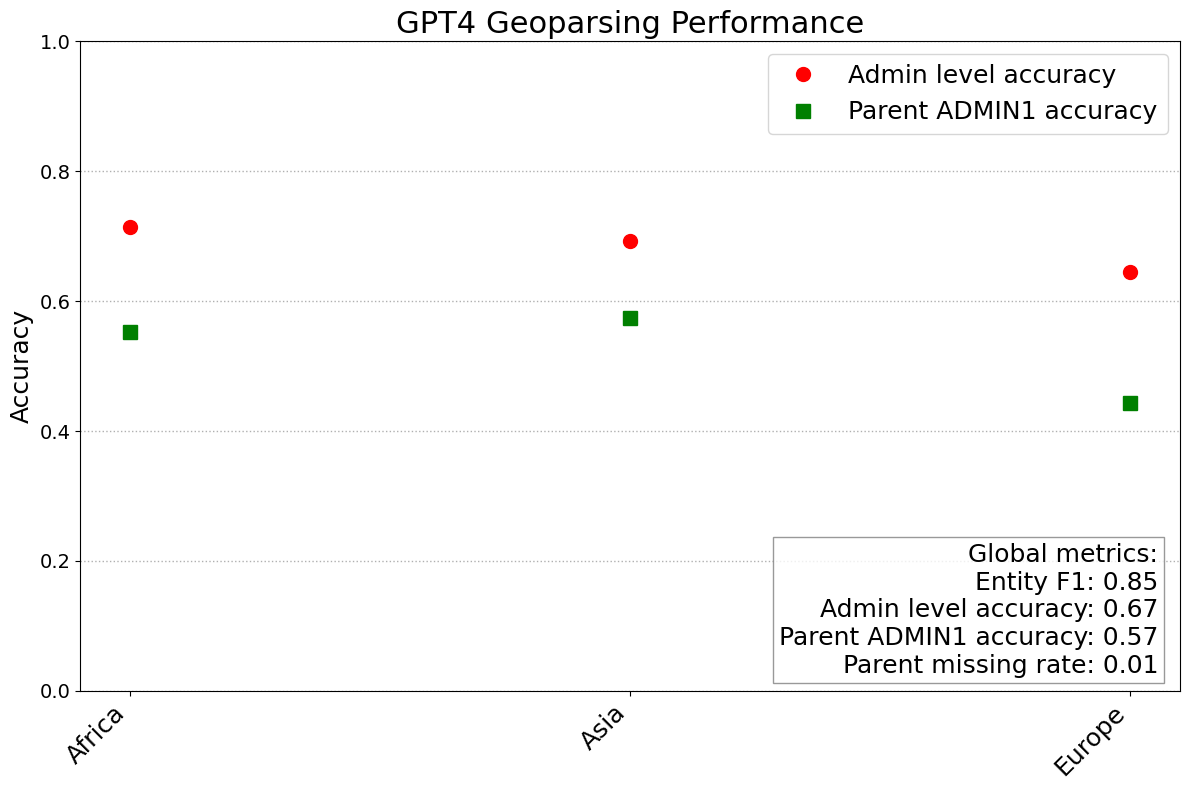

In [43]:
import matplotlib.pyplot as plt
import numpy as np

continents = plot_df["continent"]
x = np.arange(len(continents))

fig, ax = plt.subplots(figsize=(12, 8))


ax.plot(
    x,
    plot_df["admin_level_accuracy"],
    'o',
    color='red',
    label='Admin level accuracy',
    markersize=10
)

ax.plot(
    x,
    plot_df["parent_ADMIN1_accuracy"],
    's',
    color='green',
    label='Parent ADMIN1 accuracy',
    markersize=10
)


ax.set_xticks(x)
ax.set_xticklabels(continents, rotation=45, ha='right', fontsize=18)


ax.set_ylim(0, 1)
ax.set_ylabel("Accuracy", fontsize=18)
ax.set_title("GPT4 Geoparsing Performance", fontsize=22)


ax.yaxis.grid(True, linestyle=':', linewidth=1)
ax.xaxis.grid(False)


ax.legend(fontsize=18)


global_text = (
    f"Global metrics:\n"
    f"Entity F1: {global_metrics['entity_f1']:.2f}\n"
    f"Admin level accuracy: {global_metrics['admin_level_accuracy']:.2f}\n"
    f"Parent ADMIN1 accuracy: {global_metrics['parent_ADMIN1_accuracy']:.2f}\n"
    f"Parent missing rate: {global_metrics['parent_missing_rate']:.2f}"
)
ax.text(
    0.98, 0.02, global_text,
    transform=ax.transAxes,
    fontsize=18,
    verticalalignment='bottom',
    horizontalalignment='right',
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray')
)

ax.tick_params(axis='y', labelsize=14)

plt.tight_layout()

plt.show()
